# Mathematical Foundation for AI Systems

This notebook walks through every topic from the session with **runnable code and visualizations**.
Each section includes:
- A short recap of the concept
- A **🔎 Deeper Intuition** block — a relatable analogy plus the formula broken down term by term
- A small worked example with code
- A visualization to build intuition
- A "Try it yourself" cell you can edit and re-run

Run the cells in order — each section is self-contained but builds on the imports below.

## Setup
Run this first — it imports everything used in the notebook.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from math import comb, factorial, exp

# Consistent, friendly plot styling for the whole notebook
plt.rcParams["figure.figsize"] = (7, 4)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams["font.size"] = 11

PRIMARY = "#1B1F3B"
SECONDARY = "#3A6EA5"
ACCENT = "#F4A300"
ACCENT2 = "#E4572E"

print("Setup complete. Ready to go!")

Setup complete. Ready to go!


## 1. AI Mathematics Mindset — Permutations & Combinations

**Concept:** When order doesn't matter, we count possibilities using **combinations**:

$$ {}^nC_r = \frac{n!}{r!(n-r)!} $$

**Example:** An ice-cream sundae with 3 flavors is made from 5 available flavors. How many different sundaes are possible?

### 🔎 Deeper Intuition

**Think of it like this:** picking a 3-person project team from 5 candidates. It doesn't matter who you name
first — Alice-Bob-Carla is the same team as Carla-Alice-Bob. Combinations count *groups*, not *orderings*.

Breaking down the formula, term by term:
- **n!** — all the ways to arrange every candidate in some order (a big number)
- **r!** — divides out the internal orderings of the r people you chose (order within the team doesn't matter)
- **(n−r)!** — divides out the orderings of the people you *didn't* choose (they don't matter either)
- **Result** — what's left is purely the number of distinct groups, with all ordering noise removed

In [2]:
n, r = 5, 3
sundae_combos = comb(n, r)
print(f"Number of possible sundaes: {n}C{r} = {sundae_combos}")

Number of possible sundaes: 5C3 = 10


**Visualization:** How the number of combinations grows as we choose more flavors out of 5 available.

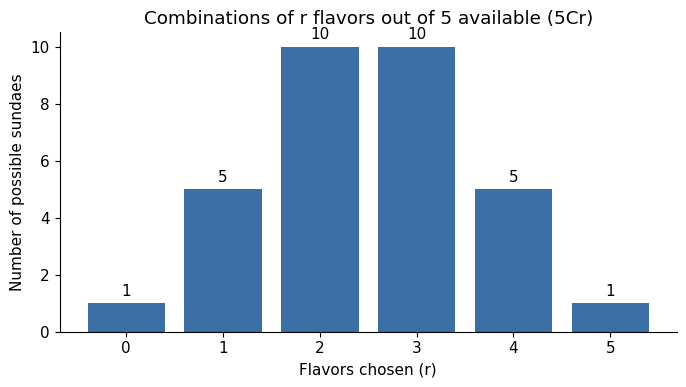

In [3]:
n = 5
choices = list(range(0, n + 1))
combos = [comb(n, r) for r in choices]

fig, ax = plt.subplots()
bars = ax.bar(choices, combos, color=SECONDARY)
ax.bar_label(bars, padding=3)
ax.set_xlabel("Flavors chosen (r)")
ax.set_ylabel("Number of possible sundaes")
ax.set_title(f"Combinations of r flavors out of {n} available (5Cr)")
ax.set_xticks(choices)
plt.tight_layout()
plt.show()

**Try it yourself:** A marketing team has 6 channels and wants to run a campaign using exactly 3 at once. How many combinations exist?

In [4]:
n, r = 6, 3
print(f"{n}C{r} =", comb(n, r))

6C3 = 20


## 2. Probability Foundations — Bayes' Theorem

**Concept:** Bayes' Theorem updates the probability of an event given new evidence.

**Example:** A diagnostic test is 85% accurate for people who have an illness, and 97% accurate for people who don't.
About 1.2% of the population has the illness. If a person tests positive, what's the real chance they have it?

We'll solve this using the "natural frequency" method — imagining 1,000 people — which is much more intuitive than plugging into the raw formula.

### 🔎 Deeper Intuition

**Think of it like this:** a detective updating a hunch. Before any evidence, you have a starting suspicion
(the **prior**). A new clue arrives (the **evidence**). Bayes' Theorem tells you exactly how much to revise
your suspicion — no more, no less.

$$ P(A|B) = \frac{P(B|A) \times P(A)}{P(B)} $$

- **P(A)** — the prior: how likely A was before you saw any evidence
- **P(B\|A)** — the likelihood: how likely the evidence is, assuming A is true
- **P(B)** — the total evidence: how likely you'd see this evidence under any scenario at all
- **P(A\|B)** — the posterior: your updated belief about A, now that you've seen the evidence

In [4]:
population = 1000
illness_rate = 0.012
true_positive_rate = 0.85     # sensitivity
false_positive_rate = 1 - 0.97  # 1 - specificity

has_illness = population * illness_rate
no_illness = population - has_illness

true_positives = has_illness * true_positive_rate
false_positives = no_illness * false_positive_rate

total_positive = true_positives + false_positives
real_chance = true_positives / total_positive

print(f"Out of {population} people:")
print(f"  {has_illness:.0f} actually have the illness -> {true_positives:.0f} test positive")
print(f"  {no_illness:.0f} do not have the illness   -> {false_positives:.0f} test positive anyway")
print(f"  Total testing positive: {total_positive:.0f}")
print(f"\nReal chance of illness given a positive test: {real_chance:.1%}")

Out of 1000 people:
  12 actually have the illness -> 10 test positive
  988 do not have the illness   -> 30 test positive anyway
  Total testing positive: 40

Real chance of illness given a positive test: 25.6%


**Visualization:** Out of everyone who tests positive, how many actually have the illness vs. a false alarm?

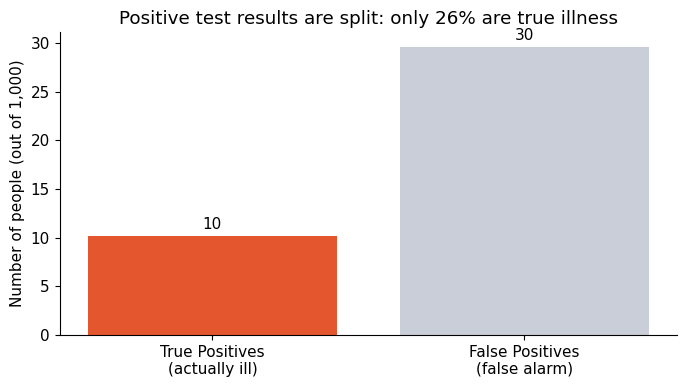

In [5]:
labels = ["True Positives\n(actually ill)", "False Positives\n(false alarm)"]
values = [true_positives, false_positives]
colors = [ACCENT2, "#C9CED9"]

fig, ax = plt.subplots()
bars = ax.bar(labels, values, color=colors)
ax.bar_label(bars, fmt="%.0f", padding=3)
ax.set_ylabel("Number of people (out of 1,000)")
ax.set_title(f"Positive test results are split: only {real_chance:.0%} are true illness")
plt.tight_layout()
plt.show()

**Try it yourself:** What happens to the real chance of illness if the illness rate were 5% instead of 1.2%? Change `illness_rate` below and re-run.

In [6]:
illness_rate_v2 = 0.05
has_illness_v2 = population * illness_rate_v2
no_illness_v2 = population - has_illness_v2
tp_v2 = has_illness_v2 * true_positive_rate
fp_v2 = no_illness_v2 * false_positive_rate
real_chance_v2 = tp_v2 / (tp_v2 + fp_v2)

print(f"With a {illness_rate_v2:.0%} illness rate, real chance given positive test: {real_chance_v2:.1%}")
print(f"(compare to {real_chance:.1%} at a {illness_rate:.1%} illness rate)")

With a 5% illness rate, real chance given positive test: 59.9%
(compare to 25.6% at a 1.2% illness rate)


## 3. Distributions & Sampling — Binomial & Poisson

**Binomial:** models the number of "successes" out of a fixed number of yes/no trials.
**Poisson:** models how many times a rare event happens in a fixed time window.

**Example (Binomial):** A metro rail company surveys 8 senior citizens; 60% historically say "Yes" to liking a new feature.
What does the full probability distribution look like across 0–8 "Yes" responses?

### 🔎 Deeper Intuition

**Think of it like this:** flipping a weighted coin several times (**binomial**) versus counting rare pings on a
Geiger counter over an hour (**Poisson**). One counts successes out of a known number of tries; the other counts
rare events with no fixed number of "tries" at all.

$$ \text{Binomial: } P(X=k) = \binom{n}{k} p^k (1-p)^{n-k} \qquad \text{Poisson: } P(X=k) = \frac{e^{-\lambda}\lambda^k}{k!} $$

- **nCk** — the number of different orders in which k successes could occur among n trials
- **p^k (1−p)^(n−k)** — the probability of one specific arrangement of k successes and (n−k) failures
- **λ (lambda)** — the average rate of a rare event (e.g., 2 machines down on average)
- **e^−λ λ^k / k!** — the probability of observing exactly k events, given that average rate

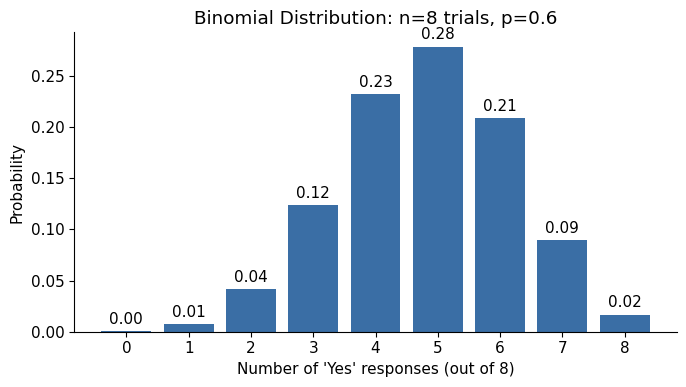

P(exactly 3 say Yes) = 0.124


In [7]:
def binomial_pmf(n, p, k):
    return comb(n, k) * (p ** k) * ((1 - p) ** (n - k))

n, p = 8, 0.6
k_values = list(range(0, n + 1))
probs = [binomial_pmf(n, p, k) for k in k_values]

fig, ax = plt.subplots()
bars = ax.bar(k_values, probs, color=SECONDARY)
ax.bar_label(bars, fmt="%.2f", padding=3)
ax.set_xlabel("Number of 'Yes' responses (out of 8)")
ax.set_ylabel("Probability")
ax.set_title("Binomial Distribution: n=8 trials, p=0.6")
ax.set_xticks(k_values)
plt.tight_layout()
plt.show()

print(f"P(exactly 3 say Yes) = {binomial_pmf(n, p, 3):.3f}")

**Example (Poisson):** A subway station averages 2 ticket machines out of operation at any time. What does the distribution of "machines down" look like?

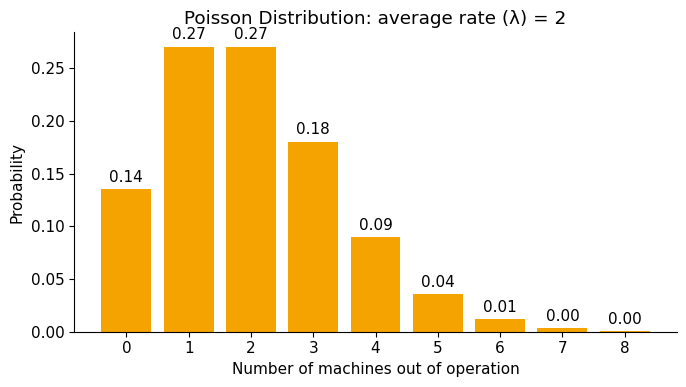

P(exactly 3 machines down) = 0.180


In [8]:
def poisson_pmf(lam, k):
    return (exp(-lam) * (lam ** k)) / factorial(k)

lam = 2
k_values = list(range(0, 9))
probs = [poisson_pmf(lam, k) for k in k_values]

fig, ax = plt.subplots()
bars = ax.bar(k_values, probs, color=ACCENT)
ax.bar_label(bars, fmt="%.2f", padding=3)
ax.set_xlabel("Number of machines out of operation")
ax.set_ylabel("Probability")
ax.set_title(f"Poisson Distribution: average rate (λ) = {lam}")
ax.set_xticks(k_values)
plt.tight_layout()
plt.show()

print(f"P(exactly 3 machines down) = {poisson_pmf(lam, 3):.3f}")

**Try it yourself:** A call center averages 3 escalations per hour. What's the probability of exactly 2 escalations in the next hour? Change `lam` and `k` below.

In [9]:
lam, k = 3, 2
print(f"P(X={k}) = {poisson_pmf(lam, k):.3f}")

P(X=2) = 0.224


## 4. Vectors, Embeddings & Semantic Space

**Concept:** Words can be represented as vectors (lists of numbers) such that similar meanings sit close together
in "semantic space". Below is a **toy 2D embedding** — real embeddings have hundreds of dimensions, but the idea
is identical.

### 🔎 Deeper Intuition

**Think of it like this:** GPS coordinates, but for meaning instead of geography. Just as [latitude, longitude]
pinpoints a location on Earth, an embedding's numbers pinpoint a concept's location in "meaning-space" — nearby
coordinates mean related meaning.

$$ \text{vector} = [x_1, x_2, \ldots, x_n] \qquad \text{distance} = \sqrt{\sum (x_i - y_i)^2} $$

- **x₁, x₂, …** — each number captures one learned aspect of meaning (discovered during training, not human-labeled)
- **n (dimensions)** — real embeddings often use hundreds of dimensions; our examples use just 2 for visualization
- **distance** — the straight-line gap between two vectors; smaller distance means more similar meaning

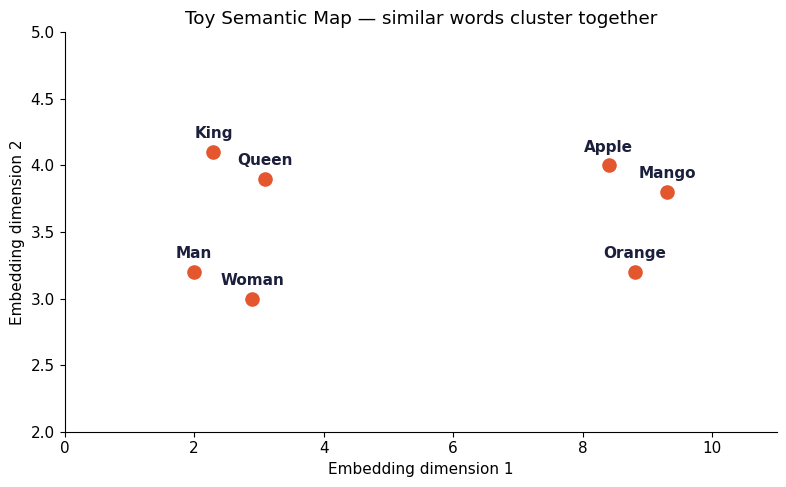

In [10]:
words = {
    "King":   (2.3, 4.1),
    "Queen":  (3.1, 3.9),
    "Man":    (2.0, 3.2),
    "Woman":  (2.9, 3.0),
    "Apple":  (8.4, 4.0),
    "Mango":  (9.3, 3.8),
    "Orange": (8.8, 3.2),
}

fig, ax = plt.subplots(figsize=(8, 5))
for word, (x, y) in words.items():
    ax.scatter(x, y, s=90, color=ACCENT2, zorder=3)
    ax.annotate(word, (x, y), textcoords="offset points", xytext=(0, 10),
                ha="center", fontsize=11, color=PRIMARY, fontweight="bold")

ax.set_title("Toy Semantic Map — similar words cluster together")
ax.set_xlabel("Embedding dimension 1")
ax.set_ylabel("Embedding dimension 2")
ax.set_xlim(0, 11)
ax.set_ylim(2, 5)
plt.tight_layout()
plt.show()

**Worked example:** Two customer profile vectors, A = [2, 3] and B = [5, 7]. What is the Euclidean distance between them?

In [11]:
A = np.array([2, 3])
B = np.array([5, 7])
distance = np.linalg.norm(A - B)
print(f"Distance between A and B: {distance:.2f}")

Distance between A and B: 5.00


**Try it yourself:** Add a third vector `C` and see which point it's closer to.

In [12]:
C = np.array([6, 8])  # try changing this
dist_A = np.linalg.norm(C - A)
dist_B = np.linalg.norm(C - B)
print(f"Distance C-A: {dist_A:.2f}")
print(f"Distance C-B: {dist_B:.2f}")
print("C is closer to", "A" if dist_A < dist_B else "B")

Distance C-A: 6.40
Distance C-B: 1.41
C is closer to B


## 5. Matrices, Tensors & Transformer Operations

**Concept:** A matrix is a rectangular grid of numbers. Multiplying matrices is one of the most common operations
inside transformer models (the architecture behind ChatGPT, Claude, Gemini, and Copilot).

**Example:** Multiply two simple 2x2 matrices.

### 🔎 Deeper Intuition

**Think of it like this:** a spreadsheet formula that combines several weighted columns into one score —
except a matrix multiplication does that for every row, against every output column, all at once.

$$ (A \times B)_{ij} = \sum_k A_{ik} \times B_{kj} $$

- **A_ik** — the i-th row of matrix A (e.g., one applicant's feature scores)
- **B_kj** — the k-th row of matrix B (e.g., one feature's weight)
- **Σ_k (sum over k)** — multiply matching entries together and add them up — a weighted total
- **(A×B)_ij** — the result: one combined number per row/column pair, repeated for the whole grid

In [13]:
M1 = np.array([[1, 2],
               [3, 4]])
M2 = np.array([[5, 6],
               [7, 8]])

result = M1 @ M2
print("M1 @ M2 =")
print(result)

M1 @ M2 =
[[19 22]
 [43 50]]


**Visualization:** Matrices as heatmaps — a helpful way to "see" what a grid of numbers looks like.

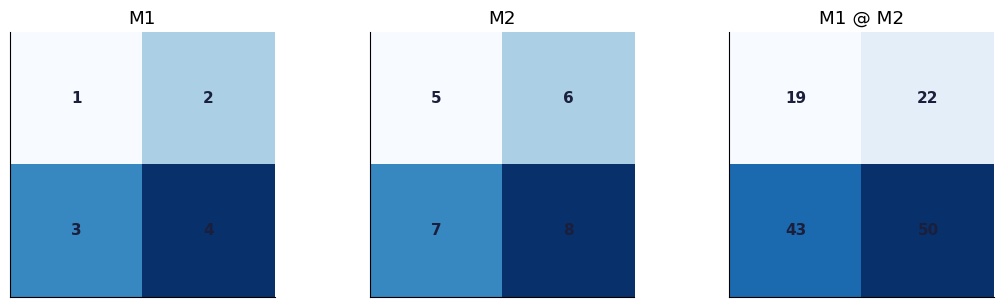

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(11, 3.2))
for ax, mat, title in zip(axes, [M1, M2, result], ["M1", "M2", "M1 @ M2"]):
    im = ax.imshow(mat, cmap="Blues")
    for (i, j), val in np.ndenumerate(mat):
        ax.text(j, i, str(val), ha="center", va="center", color=PRIMARY, fontweight="bold")
    ax.set_title(title)
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.show()

**Business example:** A loan-approval score is a weighted combination of applicant features — exactly a matrix-vector multiplication.

In [15]:
# Rows = applicants, Columns = [Income score, Credit score, Repayment score]
applicants = np.array([
    [80, 70, 90],
    [50, 60, 40],
    [95, 88, 92],
])
weights = np.array([0.5, 0.3, 0.2])

scores = applicants @ weights
for i, s in enumerate(scores, start=1):
    print(f"Applicant {i}: score = {s:.1f}")

Applicant 1: score = 79.0
Applicant 2: score = 51.0
Applicant 3: score = 92.3


## 6. Probability & Token Prediction

**Concept:** LLMs generate text by predicting a probability for every possible next token, then choosing one.

**Example:** Prompt: *"The capital of France is ___"*

### 🔎 Deeper Intuition

**Think of it like this:** a panel of judges giving raw scores to contestants, which are then converted into
percentages of votes. The **softmax** function takes the model's raw "scores" for every possible next word and
turns them into a clean probability distribution that sums to 100%.

$$ \text{softmax}(z_i) = \frac{e^{z_i}}{\sum_j e^{z_j}} $$

- **z_i** — the model's raw, unnormalized score for token i (can be any positive or negative number)
- **e^z_i** — exponentiating makes every score positive and amplifies the gap between high and low scores
- **Σ_j e^z_j** — the sum across all possible tokens, used to normalize everything into proper probabilities
- **Temperature** — a dial that scales z_i before softmax: lower temperature sharpens the top choice, higher spreads probability more evenly

In [16]:
def softmax(scores, temperature=1.0):
    scores = np.array(scores) / temperature
    exp_scores = np.exp(scores - np.max(scores))  # subtract max for numerical stability
    return exp_scores / exp_scores.sum()

# Raw, unnormalized model scores for each candidate token
raw_scores = [4.2, 1.5, 1.0, -1.0]
tokens_demo = ["Paris", "London", "Berlin", "Apple"]

for temp in [0.5, 1.0, 2.0]:
    probs = softmax(raw_scores, temperature=temp)
    formatted = ", ".join(f"{t}={p:.2f}" for t, p in zip(tokens_demo, probs))
    print(f"Temperature={temp}: {formatted}")

Temperature=0.5: Paris=0.99, London=0.00, Berlin=0.00, Apple=0.00
Temperature=1.0: Paris=0.90, London=0.06, Berlin=0.04, Apple=0.00
Temperature=2.0: Paris=0.65, London=0.17, Berlin=0.13, Apple=0.05


**Visualization:** How temperature reshapes the same raw scores into sharper vs. flatter probability distributions.

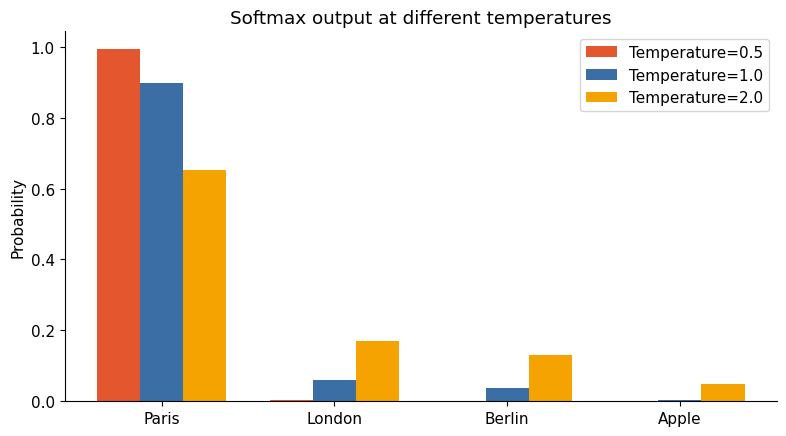

In [17]:
fig, ax = plt.subplots(figsize=(8, 4.5))
x = np.arange(len(tokens_demo))
width = 0.25
temps = [0.5, 1.0, 2.0]
colors_temp = [ACCENT2, SECONDARY, ACCENT]

for i, temp in enumerate(temps):
    probs = softmax(raw_scores, temperature=temp)
    ax.bar(x + (i - 1) * width, probs, width, label=f"Temperature={temp}", color=colors_temp[i])

ax.set_xticks(x)
ax.set_xticklabels(tokens_demo)
ax.set_ylabel("Probability")
ax.set_title("Softmax output at different temperatures")
ax.legend()
plt.tight_layout()
plt.show()

**Try it yourself:** Lower the temperature toward 0.1 or raise it toward 5.0 in the cells above — notice how a low temperature makes the model almost always pick 'Paris', while a high temperature makes the choices nearly equally likely.

**Example (fixed probabilities):** Prompt: *"The capital of France is ___"*

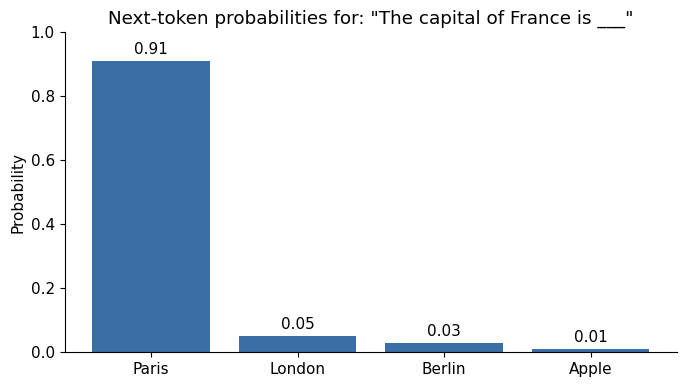

Model's top prediction: 'Paris'


In [18]:
tokens = ["Paris", "London", "Berlin", "Apple"]
probabilities = [0.91, 0.05, 0.03, 0.01]

fig, ax = plt.subplots()
bars = ax.bar(tokens, probabilities, color=SECONDARY)
ax.bar_label(bars, fmt="%.2f", padding=3)
ax.set_ylabel("Probability")
ax.set_title('Next-token probabilities for: "The capital of France is ___"')
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

top_token = tokens[int(np.argmax(probabilities))]
print(f"Model's top prediction: '{top_token}'")

**Try it yourself:** Change the probabilities below to simulate a more "uncertain" model and see how the chart changes.

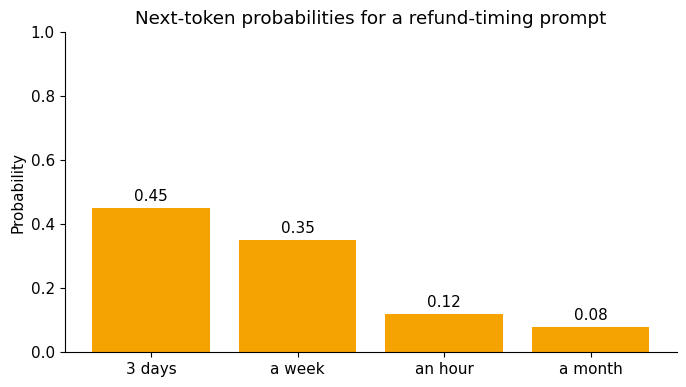

In [19]:
tokens_v2 = ["3 days", "a week", "an hour", "a month"]
probs_v2 = [0.45, 0.35, 0.12, 0.08]  # try making these more even

fig, ax = plt.subplots()
bars = ax.bar(tokens_v2, probs_v2, color=ACCENT)
ax.bar_label(bars, fmt="%.2f", padding=3)
ax.set_ylabel("Probability")
ax.set_title('Next-token probabilities for a refund-timing prompt')
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

## 7. Calculus, Gradients & Learning

**Concept:** Gradient descent nudges a model's parameters, step by step, to reduce prediction error.

**Example:** A tiny model `y = w * x` tries to learn `w` so that predictions match the actual value.

### 🔎 Deeper Intuition

**Think of it like this:** walking down a foggy hill blindfolded. You can't see the bottom, but you can feel
which direction slopes downward under your feet. You take a small step that way, feel again, and repeat —
that's exactly what gradient descent does with error instead of altitude.

$$ w_{new} = w_{old} - \text{learning\_rate} \times \frac{\partial \text{Loss}}{\partial w} $$

- **Loss** — a number measuring how wrong the model's prediction is (e.g., squared error)
- **∂Loss/∂w** — the gradient: how much the loss would change if we nudged w slightly — the "slope you feel underfoot"
- **learning_rate** — how big a step to take each time; too large overshoots, too small learns painfully slowly
- **w_new** — the updated parameter, moved a small step in the downhill (error-reducing) direction

In [20]:
x, y_actual = 3, 8       # one training example
w = 0.5                  # starting guess
learning_rate = 0.05
steps = 20

w_history, loss_history = [], []
for step in range(steps):
    y_pred = w * x
    error = y_actual - y_pred
    loss = error ** 2
    gradient = -2 * error * x   # d(loss)/dw
    w = w - learning_rate * gradient
    w_history.append(w)
    loss_history.append(loss)

print(f"Final w after {steps} steps: {w:.3f}")
print(f"Final prediction: {w * x:.2f} (actual: {y_actual})")

Final w after 20 steps: 2.667
Final prediction: 8.00 (actual: 8)


**Visualization:** Watch the loss (squared error) shrink toward zero as gradient descent updates `w`.

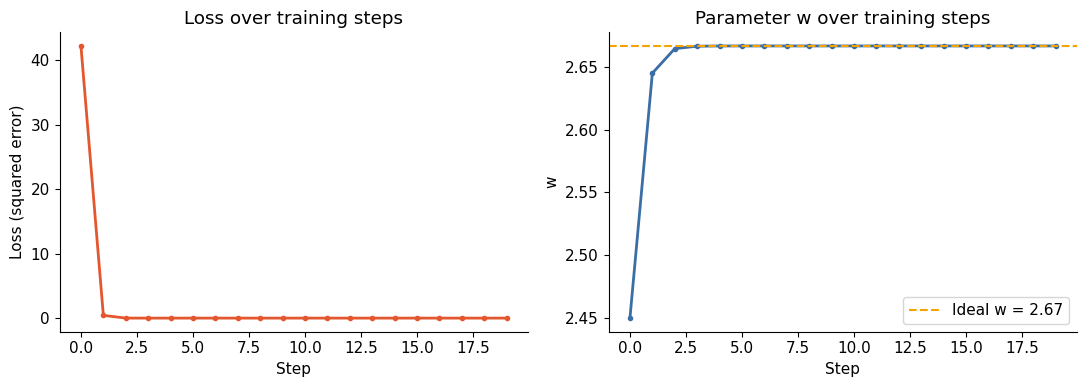

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(loss_history, color=ACCENT2, linewidth=2, marker="o", markersize=3)
axes[0].set_title("Loss over training steps")
axes[0].set_xlabel("Step")
axes[0].set_ylabel("Loss (squared error)")

axes[1].plot(w_history, color=SECONDARY, linewidth=2, marker="o", markersize=3)
axes[1].axhline(y_actual / x, color=ACCENT, linestyle="--", label=f"Ideal w = {y_actual/x:.2f}")
axes[1].set_title("Parameter w over training steps")
axes[1].set_xlabel("Step")
axes[1].set_ylabel("w")
axes[1].legend()

plt.tight_layout()
plt.show()

**Try it yourself:** Change `x`, `y_actual`, or `learning_rate` above and re-run both cells to see how training behaves differently.

## 8. Learning Rate Experimentation

### Concept

The learning rate is the most important hyperparameter in gradient descent. It controls **how big a step** we take at each iteration.

**Three scenarios:**

| Learning rate | What happens | Analogy |
|---|---|---|
| Too small (e.g. 0.01) | Takes forever to reach minimum | Baby steps down a mountain |
| Just right (e.g. 0.3) | Converges smoothly and efficiently | Confident strides |
| Too large (e.g. 1.2) | Overshoots the minimum, bounces or diverges | Giant leaps that jump over the valley |
### Interactive Cell — Change the Learning Rate

**Run the cell below. Use the slider to change the learning rate and watch:**
- How the descent path changes on the loss curve
- How many steps it takes to converge
- Whether it overshoots or oscillates

In [37]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, HTML


# ── Training Example ───────────────────────────────────────────────────────

x = 3
y_actual = 8


# ── Prediction, Loss, and Gradient ─────────────────────────────────────────

def prediction(w):
    """
    Calculate the model prediction.

    y_pred = w * x
    """
    return w * x


def loss(w):
    """
    Calculate the squared error loss.

    L(w) = (w*x - y_actual)^2
    """
    y_pred = prediction(w)

    return (y_pred - y_actual) ** 2


def gradient(w):
    """
    Calculate the gradient of the loss function.

    L(w) = (w*x - y_actual)^2

    dL/dw = 2 * (w*x - y_actual) * x
    """

    y_pred = prediction(w)

    return 2 * (y_pred - y_actual) * x


# ── Gradient Descent ───────────────────────────────────────────────────────

def run_gd(
    learning_rate=0.05,
    w_start=0.5,
    steps=20
):

    # Start with the initial weight
    w = w_start

    # Store the initial values
    hist_w = [w]
    hist_loss = [loss(w)]
    hist_prediction = [prediction(w)]

    # Perform gradient descent
    for _ in range(steps):

        # Calculate the gradient
        grad = gradient(w)

        # Update the weight
        w = w - learning_rate * grad

        # Store the updated values
        hist_w.append(w)
        hist_loss.append(loss(w))
        hist_prediction.append(prediction(w))

    return hist_w, hist_loss, hist_prediction


# ── Interactive Gradient Descent Plot ──────────────────────────────────────

def plot_interactive_gd(
    learning_rate=0.05,
    w_start=0.5,
    steps=20
):

    # Run gradient descent
    hist_w, hist_loss, hist_prediction = run_gd(
        learning_rate=learning_rate,
        w_start=w_start,
        steps=steps
    )

    # Optimal weight:
    #
    # y = wx
    #
    # w = y / x
    #
    # w = 8 / 3 ≈ 2.667

    w_optimal = y_actual / x


    # ── Create Figure ───────────────────────────────────────────────────────

    fig, (ax1, ax2) = plt.subplots(
        1,
        2,
        figsize=(14, 5)
    )


    # ── Left Plot: Loss Curve and Descent Path ──────────────────────────────

    # Generate different values of w for plotting the loss curve
    w_plot = np.linspace(-1, 5, 400)

    # Calculate loss for every w value
    loss_plot = [
        loss(w)
        for w in w_plot
    ]

    # Plot the loss curve
    ax1.plot(
        w_plot,
        loss_plot,
        linewidth=2.5,
        label='L(w) = (wx - y)²'
    )


    # Mark the optimal weight
    ax1.scatter(
        [w_optimal],
        [0],
        s=200,
        marker='*',
        zorder=6,
        label=f'Optimal w = {w_optimal:.3f}'
    )


    # Plot the path followed by gradient descent
    ax1.plot(
        hist_w,
        hist_loss,
        linestyle='--',
        linewidth=1.5,
        alpha=0.7
    )


    # Plot each gradient descent step
    ax1.scatter(
        hist_w,
        hist_loss,
        s=50,
        zorder=5
    )


    ax1.set_xlabel('w (model parameter)')
    ax1.set_ylabel('Loss')


    ax1.set_title(
        'Gradient Descent on Loss Curve\n'
        'Each dot = one gradient descent step'
    )


    ax1.legend()
    ax1.grid(True, alpha=0.3)


    # ── Right Plot: Loss During Training ────────────────────────────────────

    ax2.plot(
        range(len(hist_loss)),
        hist_loss,
        marker='o',
        markersize=4,
        linewidth=1.8,
        label='Loss'
    )


    ax2.set_xlabel('Training Step')
    ax2.set_ylabel('Loss')


    ax2.set_title(
        'Loss During Training\n'
        'Good learning rate → loss approaches 0'
    )


    ax2.legend()
    ax2.grid(True, alpha=0.3)


    # ── Print Training Information ──────────────────────────────────────────

    print(f"x = {x}")
    print(f"Actual y = {y_actual}")
    print(f"Learning rate = {learning_rate}")
    print(f"Starting w = {w_start}")
    print()


    print(
        f"{'Step':>5} "
        f"{'w':>12} "
        f"{'Prediction':>15} "
        f"{'Loss':>15}"
    )


    print("-" * 52)


    # Print the first 6 steps
    for i in range(
        min(6, len(hist_w))
    ):

        print(
            f"{i:>5} "
            f"{hist_w[i]:>12.6f} "
            f"{hist_prediction[i]:>15.6f} "
            f"{hist_loss[i]:>15.8f}"
        )


    print("...")


    # Print the final step
    print(
        f"{steps:>5} "
        f"{hist_w[-1]:>12.6f} "
        f"{hist_prediction[-1]:>15.6f} "
        f"{hist_loss[-1]:>15.8f}"
    )


    # Display the plots
    plt.tight_layout()
    plt.show()


# ── Widget Controls ────────────────────────────────────────────────────────


# Learning rate slider
learning_rate_slider = widgets.FloatSlider(
    value=0.05,
    min=0.001,
    max=0.15,
    step=0.001,
    description='Learning Rate:',
    style={
        'description_width': '160px'
    },
    layout=widgets.Layout(
        width='500px'
    ),
    readout_format='.3f'
)


# Starting weight slider
start_slider = widgets.FloatSlider(
    value=0.5,
    min=-2.0,
    max=4.0,
    step=0.1,
    description='Starting w:',
    style={
        'description_width': '160px'
    },
    layout=widgets.Layout(
        width='500px'
    ),
    readout_format='.1f'
)


# Number of gradient descent steps slider
steps_slider = widgets.IntSlider(
    value=20,
    min=1,
    max=50,
    step=1,
    description='Number of Steps:',
    style={
        'description_width': '160px'
    },
    layout=widgets.Layout(
        width='500px'
    )
)


# ── Display Interactive Plot ───────────────────────────────────────────────

display(
    HTML(
        "<b>Adjust the sliders and observe how Gradient Descent "
        "updates the parameter w:</b>"
    )
)


interactive_plot = widgets.interactive(
    plot_interactive_gd,
    learning_rate=learning_rate_slider,
    w_start=start_slider,
    steps=steps_slider
)


display(interactive_plot)

interactive(children=(FloatSlider(value=0.05, description='Learning Rate:', layout=Layout(width='500px'), max=…

## 9. Similarity Metrics & Vector Search

**Concept:** Cosine similarity measures how closely two vectors point in the same direction — the core mechanism
behind semantic search and RAG (Retrieval-Augmented Generation).

**Example:** A doctor searches "heart attack treatment". Which of 3 documents should be retrieved?

### 🔎 Deeper Intuition

**Think of it like this:** comparing compass directions instead of distances traveled. Two hikers could walk
very different distances but still be heading the exact same direction. Cosine similarity ignores "how far"
(magnitude) and measures only "which way" (direction).

$$ \cos(\theta) = \frac{A \cdot B}{\|A\| \times \|B\|} $$

- **A · B (dot product)** — multiply matching components of A and B and sum them; large when vectors point similarly
- **‖A‖, ‖B‖ (magnitude)** — the length of each vector; dividing by these removes the effect of size, leaving only direction
- **cos(θ)** — ranges from −1 (opposite direction) to 1 (identical direction); 0 means unrelated (perpendicular)
- **Why not just distance?** — two documents can differ in length (magnitude) but discuss the exact same topic (direction) — cosine similarity captures that correctly

In [22]:
def cosine_similarity(a, b):
    a, b = np.array(a), np.array(b)
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

query = [0.85, 0.8, 0.1]
documents = {
    "D1: Cardiac arrest emergency care": [0.9, 0.8, 0.1],
    "D2: Diabetes diet management":      [0.1, 0.2, 0.9],
    "D3: Flu vaccination schedule":      [0.2, 0.1, 0.7],
}

similarities = {name: cosine_similarity(query, vec) for name, vec in documents.items()}
for name, sim in sorted(similarities.items(), key=lambda kv: -kv[1]):
    print(f"{name:38s} similarity = {sim:.2f}")

best_doc = max(similarities, key=similarities.get)
print(f"\nRetrieved document: {best_doc}")

D1: Cardiac arrest emergency care      similarity = 1.00
D3: Flu vaccination schedule           similarity = 0.37
D2: Diabetes diet management           similarity = 0.31

Retrieved document: D1: Cardiac arrest emergency care


**Visualization:** Similarity scores for each candidate document.

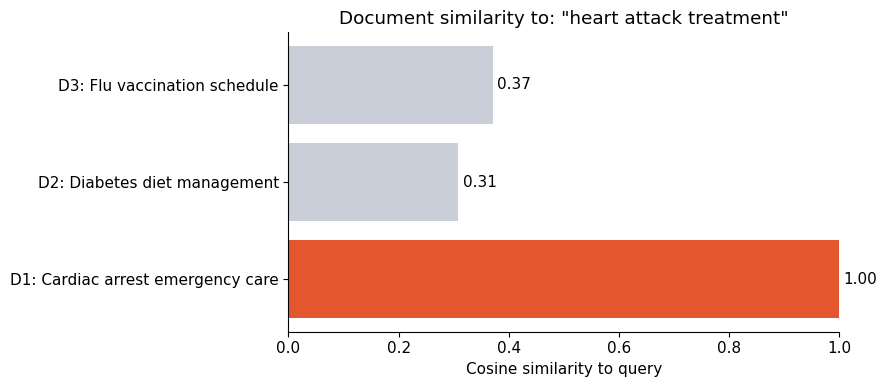

In [23]:
names = list(similarities.keys())
values = list(similarities.values())
colors = [ACCENT2 if v == max(values) else "#C9CED9" for v in values]

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(names, values, color=colors)
ax.bar_label(bars, fmt="%.2f", padding=3)
ax.set_xlabel("Cosine similarity to query")
ax.set_xlim(0, 1)
ax.set_title('Document similarity to: "heart attack treatment"')
plt.tight_layout()
plt.show()

**Try it yourself:** Add your own document vector and see how it ranks.

In [24]:
documents["D4: Your custom document"] = [0.7, 0.6, 0.3]  # try changing this
similarities = {name: cosine_similarity(query, vec) for name, vec in documents.items()}
for name, sim in sorted(similarities.items(), key=lambda kv: -kv[1]):
    print(f"{name:38s} similarity = {sim:.2f}")

D1: Cardiac arrest emergency care      similarity = 1.00
D4: Your custom document               similarity = 0.97
D3: Flu vaccination schedule           similarity = 0.37
D2: Diabetes diet management           similarity = 0.31


## 10. Optimization & AI Agent Decisioning

**Concept:** AI agents choose actions by scoring options and picking the one with the highest expected utility —
and reinforcement learning trains agents using reward signals for good vs. bad actions.

**Example:** An agentic assistant scores 3 tools for the task "Generate quarterly financial analysis".

### 🔎 Deeper Intuition

**Think of it like this:** choosing a restaurant by weighing price, distance, and rating together into one
score, then picking whichever restaurant scores highest. An AI agent does exactly this — except it repeats the
choice thousands of times, refining its scoring based on which past choices led to good outcomes.

$$ \text{action}^* = \underset{a}{\text{argmax}} \; \text{Utility}(a) \qquad \text{Return} = \sum \text{rewards over time} $$

- **Utility(a)** — a single score summarizing how good action a is expected to be, given the current situation
- **argmax_a** — "the action a that makes Utility(a) largest"; the agent doesn't average or guess, it picks the best-scoring option
- **reward** — the feedback signal an agent receives after acting (positive for good outcomes, negative for bad ones)
- **Return (Σ rewards)** — the cumulative reward over an entire sequence of actions, which reinforcement learning trains an agent to maximize

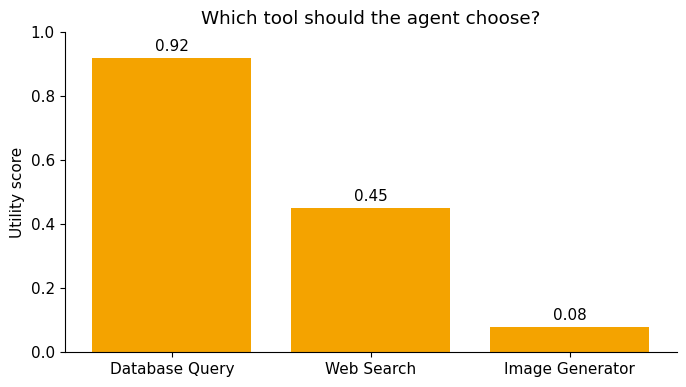

Agent selects: 'Database Query' (highest utility score)


In [25]:
tools = ["Database Query", "Web Search", "Image Generator"]
utility_scores = [0.92, 0.45, 0.08]

fig, ax = plt.subplots()
bars = ax.bar(tools, utility_scores, color=ACCENT)
ax.bar_label(bars, fmt="%.2f", padding=3)
ax.set_ylabel("Utility score")
ax.set_ylim(0, 1)
ax.set_title("Which tool should the agent choose?")
plt.tight_layout()
plt.show()

chosen_tool = tools[int(np.argmax(utility_scores))]
print(f"Agent selects: '{chosen_tool}' (highest utility score)")

**Example:** Reward optimization — an agent earns +15 for a correct retrieval, -8 for an incorrect one, and -25 for an infinite loop.

In [26]:
reward_table = {"correct_retrieval": 15, "incorrect_retrieval": -8, "infinite_loop": -25}

actions_taken = ["correct_retrieval", "correct_retrieval", "incorrect_retrieval"]
total_reward = sum(reward_table[a] for a in actions_taken)

print("Actions taken:", actions_taken)
print(f"Total reward: {total_reward}")

Actions taken: ['correct_retrieval', 'correct_retrieval', 'incorrect_retrieval']
Total reward: 22


**Visualization:** Running cumulative reward across a sequence of actions — this is what a reinforcement learning agent tries to maximize.

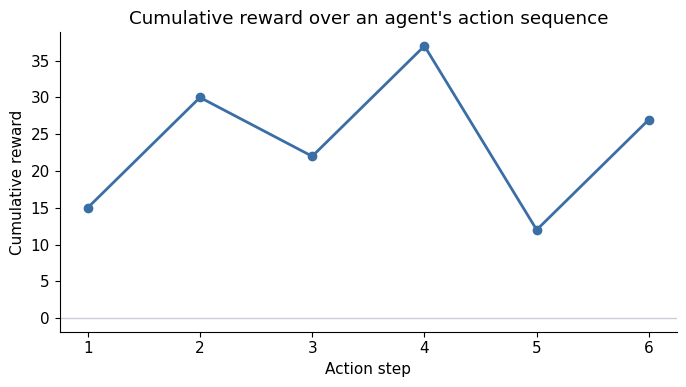

Final cumulative reward: 27


In [27]:
actions_sequence = ["correct_retrieval", "correct_retrieval", "incorrect_retrieval",
                    "correct_retrieval", "infinite_loop", "correct_retrieval"]
step_rewards = [reward_table[a] for a in actions_sequence]
cumulative = np.cumsum(step_rewards)

fig, ax = plt.subplots()
ax.plot(range(1, len(cumulative) + 1), cumulative, marker="o", color=SECONDARY, linewidth=2)
ax.axhline(0, color="#C9CED9", linewidth=1)
ax.set_xlabel("Action step")
ax.set_ylabel("Cumulative reward")
ax.set_title("Cumulative reward over an agent's action sequence")
ax.set_xticks(range(1, len(cumulative) + 1))
plt.tight_layout()
plt.show()

print(f"Final cumulative reward: {cumulative[-1]}")

**Try it yourself:** Change `actions_sequence` above (e.g., add more `infinite_loop` actions) and re-run to see how it affects the agent's cumulative reward.

## Wrap-up

You've now worked through a relatable analogy, a term-by-term formula breakdown, hands-on code, and
visualizations for every topic in the session:

1. **AI Mathematics Mindset** — permutations & combinations
2. **Probability Foundations** — Bayes' Theorem
3. **Distributions & Sampling** — Binomial & Poisson
4. **Vectors, Embeddings & Semantic Space**
5. **Matrices, Tensors & Transformer Operations**
6. **Probability & Token Prediction**
7. **Calculus, Gradients & Learning**
8. **Similarity Metrics & Vector Search**
9. **Optimization & AI Agent Decisioning**

**Next step:** Try changing the inputs in any "Try it yourself" cell above and observe how the visualizations respond —
that's the fastest way to build lasting intuition for how these ideas power real AI systems.